In [ ]:
import numpy as np
import h5py
from matplotlib import pyplot as plt
import pandas as pd

FIGSIZE=(5,3)
SAVE_PLOTS=False

In [32]:
def load_h5_data(filename):
    data = {}
    with h5py.File(filename, 'r') as f:
        for att in f.keys():
            data[int(att)] = {'CH1': [], 'CH2': []}

            for i in f[att]['CH1']:
                arr = np.array(f[att]['CH1'][i])  # Load as NumPy array
                df = pd.DataFrame(arr, columns=['t', 'V'])  # Convert to DataFrame
                data[int(att)]['CH1'].append(df)

            for i in f[att]['CH2']:
                arr = np.array(f[att]['CH2'][i])
                df = pd.DataFrame(arr, columns=['t', 'V'])
                data[int(att)]['CH2'].append(df)
    return data

In [33]:
data = load_h5_data('data/pmt_light_attenuation/signals_20250309-104658.h5')
data 

{0: {'CH1': [             t    V
   0    -0.000490 -0.8
   1    -0.000489 -0.8
   2    -0.000488 -0.8
   3    -0.000487 -0.8
   4    -0.000486 -1.0
   ...        ...  ...
   2447  0.001957 -0.8
   2448  0.001958 -0.8
   2449  0.001959 -0.8
   2450  0.001960 -0.8
   2451  0.001961 -0.8
   
   [2452 rows x 2 columns],
                t    V
   0    -0.000490 -0.8
   1    -0.000489 -0.8
   2    -0.000488 -0.8
   3    -0.000487 -0.8
   4    -0.000486 -0.8
   ...        ...  ...
   2447  0.001957 -0.8
   2448  0.001958 -0.8
   2449  0.001959 -0.8
   2450  0.001960 -0.8
   2451  0.001961 -0.8
   
   [2452 rows x 2 columns],
                t    V
   0    -0.000490 -0.8
   1    -0.000489 -0.8
   2    -0.000488 -0.8
   3    -0.000487 -0.8
   4    -0.000486 -0.8
   ...        ...  ...
   2447  0.001957 -0.8
   2448  0.001958 -0.8
   2449  0.001959 -0.8
   2450  0.001960 -0.8
   2451  0.001961 -0.8
   
   [2452 rows x 2 columns],
                t    V
   0    -0.000490 -1.0
   1    -0.000489 -1

In [48]:

def select_waveform(data, att, channel):
    waveforms = data[att][channel]
    waveforms.sort(key=lambda x: x['V'].max())  # Sort by time
    df = waveforms[2]
    # select time between -400 and 1000 us
    df = df[(df['t'] > -400e-6) & (df['t'] < 1000e-6)] 
    return df.copy()
df = select_waveform(data, 10, 'CH1')
df['us'] = df['t'] * 1e6
df

,t,V,us
90,-0.000400,-0.76,-400.0
91,-0.000399,-0.76,-399.0
92,-0.000398,-0.76,-398.0
93,-0.000397,-0.76,-397.0
94,-0.000396,-0.76,-396.0
...,...,...,...
1485,0.000995,-0.80,995.0
1486,0.000996,-0.84,996.0
1487,0.000997,-0.80,997.0
1488,0.000998,-0.80,998.0


t1: -47.000000000 us
t2: -46.000000000 us
tau: 253.021992743 us
fall time 10%:  -582.6046686896142
fall time 90%:  -26.65852762817028
fall time 90%-10%:  555.9461410614439
Rise time: 1.000000000 us


/tmp/ipykernel_8656/3855636989.py:46: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exp_func, t, v, maxfev=10000, p0=[1, 1e-6, df['V'].max()])


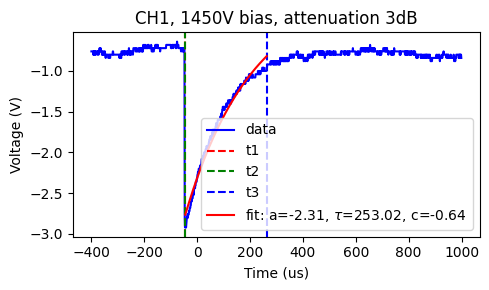

In [49]:

fig, ax = plt.subplots(figsize=FIGSIZE)
# ax.plot(df['us'], df['V'])
ax.plot(df['us'], df['V'], 'b-', label='data')
ax.set_xlabel('Time (us)')
ax.set_ylabel('Voltage (V)')
ax.set_title('CH1, 1450V bias, attenuation 3dB')

def find_begin_end_rise(df):
    threshold = 0.1 * df['V'].min() + df['V'].max()
    index = df[df['V'] < threshold].index[0]
    t1 = df['us'][index]
    max_index = df['V'].idxmin()
    t2 = df['us'][max_index]
    return t1, t2

def find_rise_time(df):
    t1, t2 = find_begin_end_rise(df)
    print(f"t1: {t1:.9f} us")
    print(f"t2: {t2:.9f} us")
    return t2 - t1

def find_begin_end_fall(df):
    threshold = 0.1*df['V'].min() + df['V'].max()
    index = df[df['V'] < threshold].index[-1]
    t2 = df['us'][index]
    max_index = df['V'].idxmin()
    t1 = df['us'][max_index]
    return t1, t2

rise_time = find_rise_time(df)
t1, t2 = find_begin_end_rise(df)
ax.axvline(x=t1, color='r', linestyle='--', label='t1')
ax.axvline(x=t2, color='g', linestyle='--', label='t2')
_, t3 = find_begin_end_fall(df)
ax.axvline(x=t3, color='b', linestyle='--', label='t3')

# fit an exponential to the fall time
from scipy.optimize import curve_fit

def exp_func(x, a, b, c):
    c=0
    return a * np.exp(-b * x) + c
df_fit = df[(df['us'] > t2) & (df['us'] < t3)]
t = df_fit['us'].values
v = df_fit['V'].values
popt, pcov = curve_fit(exp_func, t, v, maxfev=10000, p0=[1, 1e-6, df['V'].max()])
ax.plot(t, exp_func(t, *popt), 'r-', label=rf'fit: a={popt[0]:.2f}, $\tau$={1/popt[1]:.2f}, c={popt[2]:.2f}')

tau = 1/popt[1]
print(f"tau: {tau:.9f} us")
t_10 = np.log(0.1) * tau
t_90 = np.log(0.9) * tau
print('fall time 10%: ', t_10)
print('fall time 90%: ', t_90)
print('fall time 90%-10%: ', t_90 - t_10)

# ax.plot(df_fit['us'], df_fit['V'], 'r-', label='data')

plt.legend()
plt.tight_layout()


print(f"Rise time: {rise_time:.9f} us")
if SAVE_PLOTS:
    plt.savefig('plots/pmt_light_attenuation_tests/pmt1/example_time_fitting.png', dpi=300, bbox_inches='tight')

In [50]:

def calculate_fall_time(df):
    v_min = df['V'].min()
    v_max=df['V'].max()
    t1, t2 = find_begin_end_fall(df)
    df_fit = df[(df['us'] > t1) & (df['us'] < t2)]
    t = df_fit['us'].values
    v = df_fit['V'].values

    popt, pcov = curve_fit(exp_func, t, v, maxfev=10000, p0=[1, 1e-6, v_max])
    tau = 1/popt[1]
    t_10 = np.log(0.1) * tau
    t_90 = np.log(0.9) * tau
    t_fall = t_90 - t_10
    return t_fall

In [51]:

atts = sorted(data.keys())
atts = np.array(atts)
atts = atts[atts < 15]
atts

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 12, 14])

In [52]:

rise_times_ch1 = []
fall_times_ch1 = []
rise_times_ch2 = []
fall_times_ch2 = []


for v in atts:
    df = select_waveform(data, v, 'CH1')
    df = df.copy()
    df['us'] = df['t'] * 1e6
    rise_time = find_rise_time(df)
    rise_times_ch1.append(rise_time)
    fall_time = calculate_fall_time(df)
    fall_times_ch1.append(fall_time)

    df = select_waveform(data, v, 'CH2')
    df = df.copy()
    df['us'] = df['t'] * 1e6
    rise_time = find_rise_time(df)
    rise_times_ch2.append(rise_time)
    fall_time = calculate_fall_time(df)
    fall_times_ch2.append(fall_time)


fall_times_ch1 = np.array(fall_times_ch1)
rise_times_ch1 = np.array(rise_times_ch1)
fall_times_ch2 = np.array(fall_times_ch2)
rise_times_ch2 = np.array(rise_times_ch2)

t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -45.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -45.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -47.000000000 us
t2: -44.000000000 us
t1: -48.000000000 us
t2: -45.000000000 us
t1: -48.000000000 us
t2: -45.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -47.000000000 us
t2: -45.000000000 us
t1: -48.000000000 us
t2: -47.000000000 us
t1: -48.000000000 us
t2: -45.000000000 us
t1: -47.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -47.000000000 us
t1: -48.000000000 us
t2: -46.00000

/tmp/ipykernel_8656/3272295294.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exp_func, t, v, maxfev=10000, p0=[1, 1e-6, v_max])
/tmp/ipykernel_8656/3272295294.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exp_func, t, v, maxfev=10000, p0=[1, 1e-6, v_max])
/tmp/ipykernel_8656/3272295294.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exp_func, t, v, maxfev=10000, p0=[1, 1e-6, v_max])
/tmp/ipykernel_8656/3272295294.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exp_func, t, v, maxfev=10000, p0=[1, 1e-6, v_max])
/tmp/ipykernel_8656/3272295294.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exp_func, t, v, maxfev=10000, p0=[1, 1e-6, v_max])
/tmp/ipykernel_8656/3272295294.py:9: OptimizeWarning: Covariance of the parameters could n

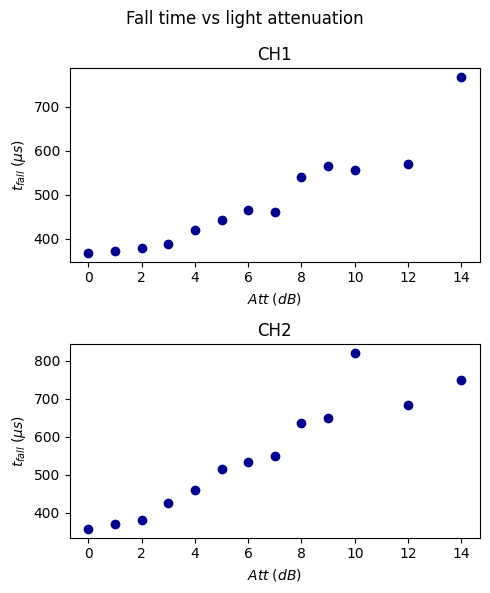

In [53]:

fig, ax = plt.subplots(2, 1, figsize=(5,6))
ax[0].scatter(atts, fall_times_ch1, label='Fall time', color='darkblue')
ax[0].set_xlabel(r'$Att \; (dB)$')
ax[0].set_ylabel(r'$t_{fall} \; (\mu s)$')
ax[0].set_title('CH1')
ax[1].scatter(atts, fall_times_ch2, label='Fall time', color='darkblue')
ax[1].set_xlabel(r'$Att \; (dB)$')
ax[1].set_ylabel(r'$t_{fall} \; (\mu s)$')
ax[1].set_title('CH2')

fig.suptitle('Fall time vs light attenuation')
plt.tight_layout()

# ax.legend()
if SAVE_PLOTS:
    plt.savefig('plots/pmt_light_attenuation_tests/pmt1/fall_times.png', dpi=300, bbox_inches='tight')
plt.show()

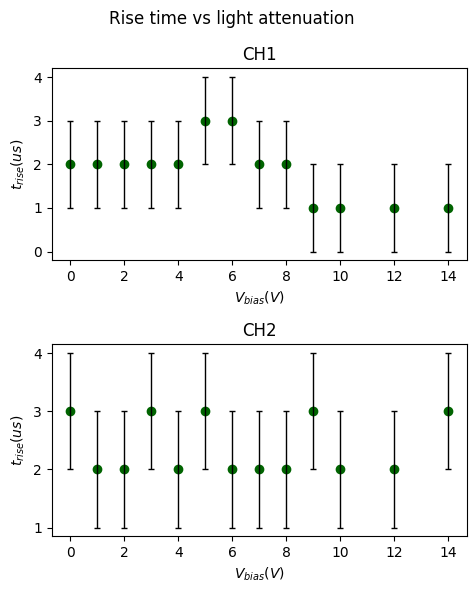

In [54]:
fig, ax = plt.subplots(2,1,figsize=(5,6))
ax[0].scatter(atts, rise_times_ch1, label='Rise time', color='darkgreen', zorder=2)
ax[0].errorbar(atts, rise_times_ch1, yerr=1, fmt='none', color='black', capsize=2,capthick=1,elinewidth=1, label='Rise time')

ax[0].set_xlabel(r'$V_{bias} (V)$')
ax[0].set_ylabel(r'$t_{rise} (us)$')
ax[0].set_title('CH1')

ax[1].scatter(atts, rise_times_ch2, label='Rise time', color='darkgreen', zorder=2)
ax[1].errorbar(atts, rise_times_ch2, yerr=1, fmt='none', color='black', capsize=2,capthick=1,elinewidth=1, label='Rise time')
ax[1].set_xlabel(r'$V_{bias} (V)$')
ax[1].set_ylabel(r'$t_{rise} (us)$')
ax[1].set_title('CH2')
fig.suptitle('Rise time vs light attenuation')
plt.tight_layout()


# ax.legend()
if SAVE_PLOTS:
    plt.savefig('plots/pmt_light_attenuation_tests/pmt1/rise_times.png', dpi=300, bbox_inches='tight')
plt.show()